In [2]:
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import mplhep as hep
hep.style.use("CMS")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)

plt.rcParams['figure.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['savefig.bbox']='tight'
plt.rcParams['legend.frameon']=True
plt.rcParams['legend.edgecolor']='white'

from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (10, 8)

import gc

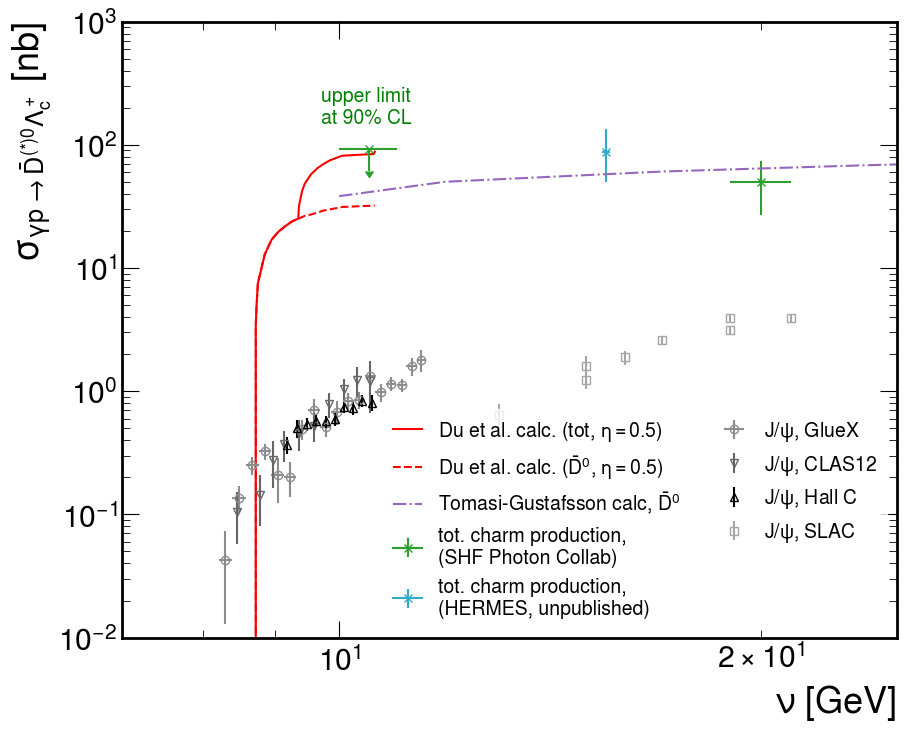

In [41]:
from io import StringIO
def plot_existing(color_slac_tot='tab:brown'):
    
    plt.ylim(1e-2, 1e3)
    plt.yscale('log')
    plt.xlabel("$\\nu$ [GeV]")
    plt.ylabel("$\\sigma_{\\gamma p\\rightarrow\\bar D^{(*)0}\\Lambda_c^+}$ [nb]")
    plt.xlim(6.5, 11.5)

#     #Du et al calculations:
#     from io import StringIO
#     import pandas as pd
#     calc_str = StringIO("""nu,nb
#         8.716,0.000
#         8.716,6.918
#         8.730,18.239
#         8.748,25.786
#         8.766,30.818
#         8.787,36.478
#         8.816,42.767
#         8.858,50.314
#         8.922,59.748
#         8.982,66.667
#         9.060,74.214
#         9.191,84.277
#         9.330,92.453
#         9.475,99.371
#         9.660,106.289
#         9.858,111.321
#         10.064,115.723
#         10.376,120.126
#         10.585,122.013
#         10.599,122.013
#         """)

#     calc = pd.read_csv(calc_str, sep=",")
#     plt.plot(calc.nu, calc.nb, label='Du et al. calc. ($\\bar D^0$, $\\eta=1$)', color='r')

#     calc_str = StringIO("""nu,nb
#         8.716,1.887
#         8.727,4.403
#         8.762,7.547
#         8.794,10.063
#         8.830,11.950
#         8.897,15.094
#         8.965,16.981
#         9.032,18.868
#         9.113,20.755
#         9.199,22.642
#         9.273,23.899
#         9.394,25.786
#         9.521,27.044
#         9.635,28.302
#         9.730,28.931
#         10.004,30.818
#         10.241,31.447
#         10.585,32.075
#         10.603,32.075
#         """)


#     calc = pd.read_csv(calc_str, sep=",")

#     plt.plot(calc.nu, calc.nb, label='Du et al. calc. ($\\bar D^0$, $\\eta=0.5$)', color='r', ls='--')
#     plt.plot()
    
    calc_str = StringIO("""nu,nb_D0,nb_D0star
    8.714, 0,0
    8.72,3.4,0
    8.73,4.76,0
    8.75,7.5,0
    8.85,12.9,0
    8.95,17.0,0
    9.05,19.7,0
    9.15,21.8,0
    9.25,23.8,0
    9.35,25.2,0
    9.362,25.3,6.8
    9.41,25.9,16.3
    9.45,26.5,21.8
    9.55,27.2,30.6
    9.65,28.2,36.4
    9.75,29.3,40.8
    9.85,29.9,44.9
    9.95,30.6,47.6
    10.05,31.3,50.3
    10.585,32.1,52.1
    10.603,32.1,55.9
    """)
    calc = pd.read_csv(calc_str, sep=",")
    
    
    plt.plot(calc.nu, calc.eval("nb_D0+nb_D0star"), label='Du et al. calc. (tot, $\\eta=0.5$)', color='r', ls='-')
    plt.plot()
    plt.plot(calc.nu, calc.nb_D0, label='Du et al. calc. ($\\bar D^{0}$, $\\eta=0.5$)', color='r', ls='--')
    plt.plot()
    

    plt.errorbar([20], [50], [[23],[24]],[1], label='tot. charm production,\n(SHF Photon Collab)', color=color_slac_tot, marker='x')


    #87.9^{+40.7}_{-32.1} \mathrm{(stat)}\pm9.2 \mathrm{(sys)} \pm 17.6
    plt.errorbar([15.5], [87.9], [[np.sqrt(32.1**2+9.2**2+17.6**2)],[np.sqrt(40.7**2+9.2**2+17.6**2)]],[.1], label='tot. charm production,\n(HERMES, unpublished)', color='#33aacc', marker='x')
    
    plt.errorbar([10.5], [92], [92/3],[0.5], uplims=[1], color=color_slac_tot, marker='x')


    plt.plot([10.0, 11.9, 17.0, 23.6, 30.2], [38.3, 50.1, 60.7, 68.1, 73.6], color='tab:purple', ls='-.',
             label='Tomasi-Gustafsson calc, $\\bar D^0$')

    gluex_str = StringIO("""nu,nb,low,up
        8.297,0.043,0.013,0.074
        8.483,0.136,0.102,0.171
        8.669,0.251,0.207,0.292
        8.855,0.327,0.278,0.376
        9.041,0.207,0.123,0.288
        9.227,0.200,0.138,0.264
        9.407,0.491,0.401,0.580
        9.593,0.710,0.565,0.859
        9.779,0.510,0.427,0.594
        9.965,0.683,0.530,0.837
        10.151,0.837,0.701,0.963
        10.337,0.848,0.719,0.987
        10.523,1.322,1.121,1.539
        10.703,0.987,0.816,1.150
        10.890,1.150,1.013,1.305
        11.081,1.121,0.987,1.257
        11.262,1.599,1.339,1.862
        11.448,1.792,1.445,2.141
        """)

    gluex = pd.read_csv(gluex_str, sep=",")

    dx=(gluex.nu[1]-gluex.nu[0])/2
    plt.errorbar(gluex.nu, gluex.nb, [gluex.nb-gluex.low, gluex.up-gluex.nb],dx,
                 label='$J/\\psi$, GlueX', color='0.55', ls='', marker='o', fillstyle='none')

    clas12_str = StringIO("""nu,nb,dnb
        8.456,0.105,0.047
        8.784,0.144,0.063
        8.975,0.279,0.116
        9.132,0.372,0.107
        9.364,0.455,0.127
        9.603,0.525,0.139
        9.828,0.784,0.175
        10.084,1.051,0.207
        10.292,1.231,0.355
        10.521,1.213,0.550
        """)

    clas12 = pd.read_csv(clas12_str, sep=",")

    plt.errorbar(clas12.nu, clas12.nb, clas12.dnb,
                 label='$J/\\psi$, CLAS12', color='0.4', ls='', marker='v', fillstyle='none')


    hallc_str = StringIO("""nu,nb,dnb
    9.176,0.365,0.058
    9.327,0.499,0.084
    9.478,0.544,0.065
    9.629,0.573,0.063
    9.780,0.568,0.062
    9.924,0.594,0.071
    10.076,0.738,0.074
    10.227,0.731,0.087
    10.381,0.840,0.092
    10.552,0.805,0.120""")

    hallc = pd.read_csv(hallc_str, sep=",")

    plt.errorbar(hallc.nu, hallc.nb, hallc.dnb,
                 label='$J/\\psi$, Hall C', color='0', ls='', marker='^', fillstyle='none')
    

    slac_jpsi_str= StringIO("""nu,nb,low,up
        13,0.637,0.519,0.782
        15,1.599,1.357,1.923
        15,1.224,1.039,1.503
        16,1.881,1.629,2.113
        17,2.609,2.354,2.832
        19,3.921,3.612,4.170
        19,3.129,2.882,3.327
        21,3.950,3.676,4.244
    """)
    slac_jpsi = pd.read_csv(slac_jpsi_str, sep=",")

    plt.errorbar(slac_jpsi.nu, slac_jpsi.nb, [slac_jpsi.nb-slac_jpsi.low, slac_jpsi.up-slac_jpsi.nb],
                 label='$J/\\psi$, SLAC', color='0.65', ls='', marker='s', fillstyle='none')

    plt.text(9.7, 1.5e2, "upper limit\nat 90% CL", fontsize=14, color='g')

    plt.xlim(7, 25)
    plt.xscale('log')

    plt.legend(fontsize=14, loc='lower right',ncol=2)
plot_existing('tab:green')
plt.savefig("images/existing_data.pdf")

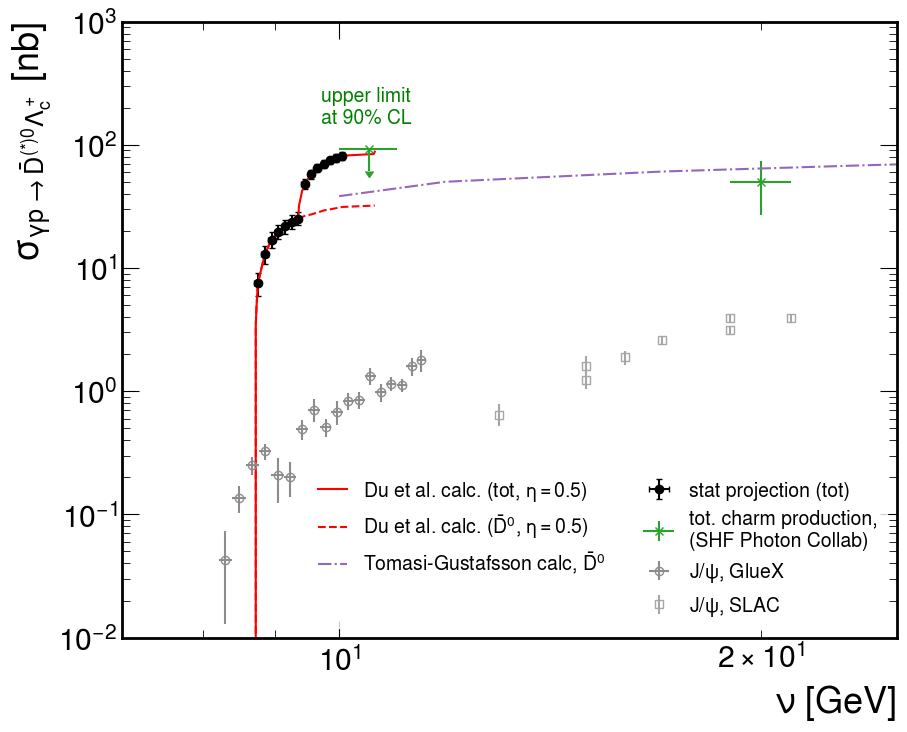

In [5]:
x=np.array((8.8, 9.0, 9.2,9.4,9.6, 9.8, 10))
#placeholder

Ntot=1300
y=2e1+0*x
dy=y/np.sqrt(Ntot/len(x))
dx=.1+0*x

from io import StringIO
import pandas as pd
calc_str = StringIO("""nu,nb_D0,nb_D0star
    8.75,7.5,0
    8.85,12.9,0
    8.95,17.0,0
    9.05,19.7,0
    9.15,21.8,0
    9.25,23.8,0
    9.35,25.2,0
    9.45,26.5,21.8
    9.55,27.2,30.6
    9.65,28.2,36.4
    9.75,29.3,40.8
    9.85,29.9,44.9
    9.95,30.6,47.6
    10.05,31.3,50.3
    """)

calc = pd.read_csv(calc_str, sep=",")

s=calc.nb_D0+calc.nb_D0star
y=calc.nu/10.6
f=(1-y+y**2/2)/y
N=1600*s*f/sum(s*f)
ds=s/np.sqrt(N)

plt.errorbar([],[],[], marker='', color='w',label=' ')
plt.errorbar(calc.nu, s, ds,.05, label="stat projection (tot)", ls='', marker='o', color='k', capsize=2.5)
plot_existing('tab:green')
plt.savefig("images/projection.pdf")

In [30]:
#W=(2010.27+2453.97)/1000 #
#np.sqrt(.9383*.9383+2*.9383*10.15)-W

np.float64(-0.0001726965199102537)

In [54]:
# check the thresholds for the sigmaCp D0 bar reaction

lambdaCpstar=2592.25/1000
sigmaCp=2452.65/1000
D0bar=1864.84/1000
D0barstar=2006.85/1000
Dpm=1869.66/1000
Dpmstar=2010.26/1000
proton=.9383

W=lambdaCpstar+D0bar
print("lambda c+* D0bar", (W**2-.9383**2)/(2*.9383))
W=lambdaCpstar+D0barstar
print("lambda c+* D0bar*", (W**2-.9383**2)/(2*.9383))

W=sigmaCp+D0bar
print("sigma c D0bar", (W**2-.9383**2)/(2*.9383))
W=sigmaCp+Dpm
print("sigma c D+-", (W**2-.9383**2)/(2*.9383))
W=sigmaCp+D0barstar
print("sigma c D0bar*", (W**2-.9383**2)/(2*.9383))
W=sigmaCp+Dpmstar
print("sigma c D+-*",(W**2-.9383**2)/(2*.9383))
W=proton+2*D0bar
print("p D0 D0bar", (W**2-.9383**2)/(2*.9383))

lambda c+* D0bar 10.116830639507619
lambda c+* D0bar* 10.80214958968347
sigma c D0bar 9.464090914472985
sigma c D+- 9.486282023926249
sigma c D0bar* 10.128281658318237
sigma c D+-* 10.14449471283172
p D0 D0bar 11.142294783331558


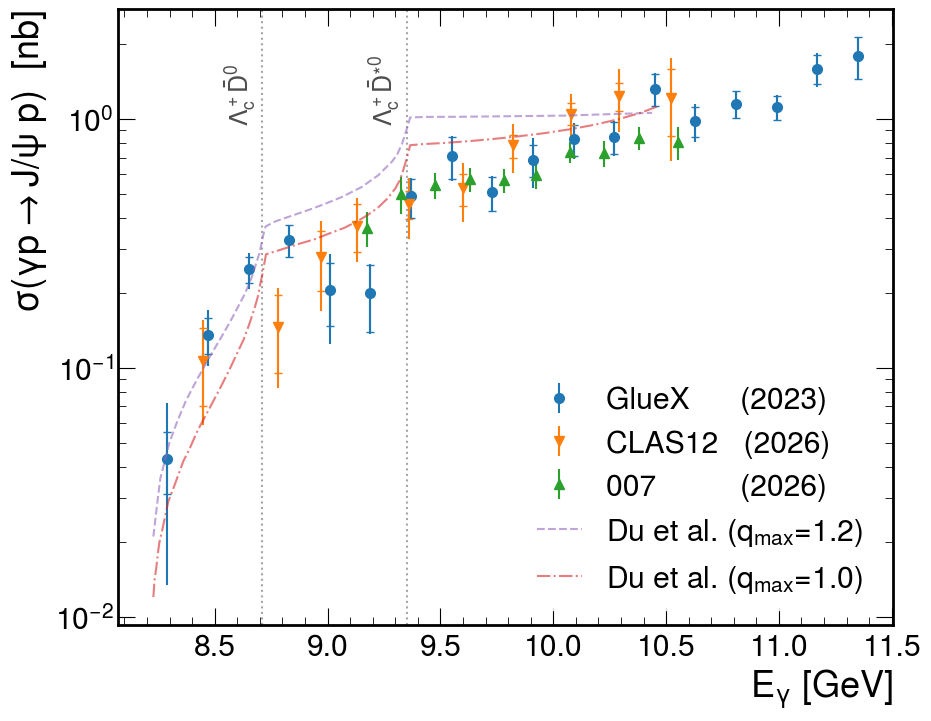

In [161]:


gluex_str = StringIO("""numin,numax,nb,dnbstat,dnbsyst
8.20,8.38,0.043,0.012,0.027
8.38,8.56,0.136,0.022,0.026
8.56,8.74,0.249,0.029,0.029
8.74,8.92,0.326,0.048,0.016
8.92,9.10,0.206,0.059,0.056
9.10,9.28,0.200,0.060,0.018
9.28,9.46,0.489,0.087,0.019
9.46,9.64,0.710,0.134,0.064
9.64,9.82,0.507,0.080,0.019
9.82,10.00,0.683,0.100,0.116
10.00,10.18,0.829,0.119,0.064
10.18,10.36,0.848,0.123,0.059
10.36,10.54,1.321,0.193,0.067
10.54,10.72,0.981,0.134,0.104
10.72,10.90,1.151,0.140,0.051
10.90,11.08,1.114,0.126,0.034
11.08,11.26,1.594,0.208,0.144
11.26,11.44,1.791,0.344,0.026
    """)

gluex = pd.read_csv(gluex_str, sep=",")

gluex['nu']=gluex.eval("(numin+numax)/2")
gluex['dnb']=gluex.eval('sqrt(dnbstat**2+dnbsyst**2)')

dx=(gluex.nu[1]-gluex.nu[0])/2
a=plt.errorbar(gluex.nu, gluex.nb, gluex.dnb,
             label='GlueX      (2023)', ls='', marker='o', markersize=7)
plt.errorbar(gluex.nu, gluex.nb, gluex.dnbstat, color=a[0].get_color(), capsize=3, ls='')

clas12_str = StringIO("""nu,nb,dnbstat,dnbsyst
    8.45,0.107,0.037,0.031
    8.78,0.146,0.051,0.037
    8.97,0.280,0.076,0.080
    9.13,0.373,0.081,0.070
    9.36,0.456,0.060,0.110
    9.60,0.526,0.078,0.116
    9.82,0.783,0.083,0.153
    10.08,1.050,0.106,0.181
    10.29,1.233,0.159,0.312
    10.52,1.220,0.363,0.405
    """)

clas12 = pd.read_csv(clas12_str, sep=",")

clas12['dnb']=clas12.eval('sqrt(dnbstat**2+dnbsyst**2)')

a=plt.errorbar(clas12.nu, clas12.nb, clas12.dnb,
             label='CLAS12   (2026)', ls='', marker='v', markersize=7)
plt.errorbar(clas12.nu, clas12.nb, clas12.dnbstat, color=a[0].get_color(), capsize=3, ls='')

hallc_str = StringIO("""nu,nb,dnb
9.176,0.365,0.058
9.327,0.499,0.084
9.478,0.544,0.065
9.629,0.573,0.063
9.780,0.568,0.062
9.924,0.594,0.071
10.076,0.738,0.074
10.227,0.731,0.087
10.381,0.840,0.092
10.552,0.805,0.120""")

hallc = pd.read_csv(hallc_str, sep=",")

plt.errorbar(hallc.nu, hallc.nb, hallc.dnb,
             label='007          (2026)', ls='', marker='^', markersize=7)





du_pred_str=((1.0,
              StringIO("""nu,nb
8.228,0.012
8.233,0.014
8.242,0.016
8.248,0.018
8.255,0.020
8.266,0.022
8.279,0.025
8.294,0.029
8.323,0.034
8.360,0.042
8.387,0.047
8.424,0.056
8.470,0.067
8.518,0.081
8.562,0.097
8.606,0.118
8.628,0.130
8.652,0.149
8.676,0.173
8.692,0.195
8.701,0.216
8.712,0.240
8.727,0.286
8.769,0.294
8.815,0.303
8.878,0.316
8.940,0.328
9.001,0.345
9.076,0.366
9.133,0.389
9.177,0.411
9.225,0.442
9.265,0.479
9.300,0.526
9.322,0.572
9.337,0.631
9.351,0.697
9.366,0.785
9.423,0.793
9.515,0.801
9.641,0.817
9.748,0.834
9.840,0.851
9.959,0.877
10.082,0.912
10.187,0.950
10.288,0.998
10.387,1.059
10.462,1.124 """)),
(1.2, StringIO("""nu,nb
8.228,0.021
8.246,0.029
8.259,0.036
8.299,0.050
8.334,0.061
8.373,0.074
8.422,0.090
8.488,0.115
8.523,0.130
8.571,0.155
8.633,0.198
8.663,0.230
8.698,0.289
8.716,0.345
8.725,0.370
8.769,0.388
8.839,0.408
8.922,0.433
8.980,0.453
9.063,0.486
9.151,0.533
9.225,0.595
9.287,0.677
9.309,0.722
9.331,0.800
9.353,0.924
9.366,1.015
9.443,1.020
9.577,1.021
10.049,1.032
10.438,1.059""")))
for i in reversed(range(2)):
    du_pred = pd.read_csv(du_pred_str[i][1], sep=",")
    plt.errorbar(du_pred.nu,du_pred.nb, label=f'Du et al. ($q_{{max}}$={du_pred_str[i][0]})', ls=['--','-.'][1-i],
                 color='tab:purple tab:red'.split()[1-i], alpha=0.6)


for i in range(2):
    x=[8.71,9.35][i]
    txt=("$\\Lambda_c^+\\bar D^{0}$","$\\Lambda_c^+\\bar D^{\\ast 0}$")[i]
    plt.axvline(x, ls=':', color='0.5', alpha=0.7)
    plt.text(x-.02, 1.03, txt, rotation=90, ha='right', fontsize=18, color='0.3')


plt.xlabel("$E_\\gamma$ [GeV]")
plt.ylabel("$\\sigma(\\gamma p\\to J/\\psi\,\,p)$  [nb]")
plt.legend(loc='lower right')
plt.yscale('log')

plt.savefig("images/Jpsi.pdf")
# slac_jpsi_str= StringIO("""nu,nb,low,up
#     13,0.637,0.519,0.782
#     15,1.599,1.357,1.923
#     15,1.224,1.039,1.503
#     16,1.881,1.629,2.113
#     17,2.609,2.354,2.832
#     19,3.921,3.612,4.170
#     19,3.129,2.882,3.327
#     21,3.950,3.676,4.244
# """)
# slac_jpsi = pd.read_csv(slac_jpsi_str, sep=",")

# # plt.errorbar(slac_jpsi.nu, slac_jpsi.nb, [slac_jpsi.nb-slac_jpsi.low, slac_jpsi.up-slac_jpsi.nb],
# #              label='$J/\\psi$, SLAC', color='0.65', ls='', marker='s', fillstyle='none')

(8.5, 11.0)

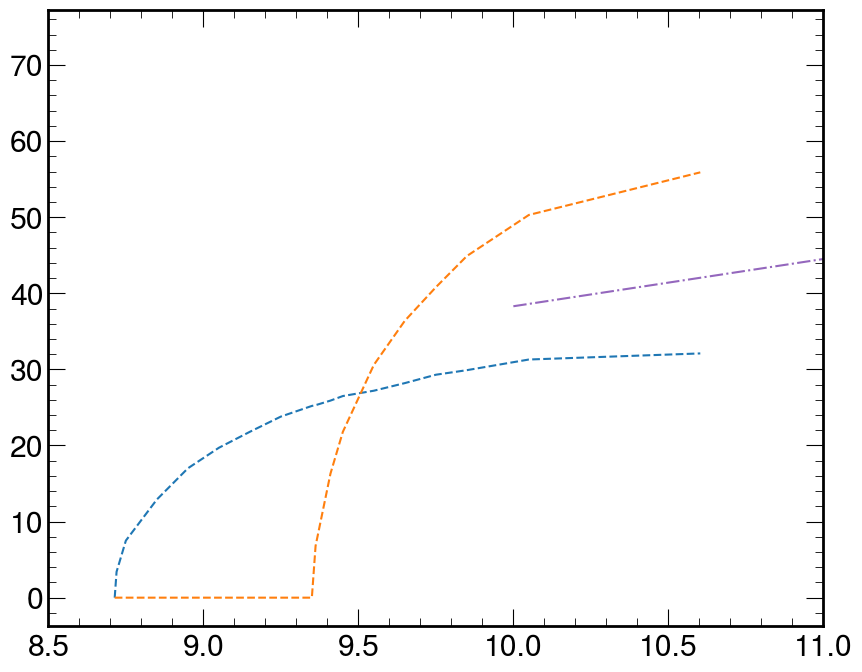

In [119]:
calc_str = StringIO("""nu,nb_D0,nb_D0star
8.714, 0,0
8.72,3.4,0
8.73,4.76,0
8.75,7.5,0
8.85,12.9,0
8.95,17.0,0
9.05,19.7,0
9.15,21.8,0
9.25,23.8,0
9.35,25.2,0
9.362,25.3,6.8
9.41,25.9,16.3
9.45,26.5,21.8
9.55,27.2,30.6
9.65,28.2,36.4
9.75,29.3,40.8
9.85,29.9,44.9
9.95,30.6,47.6
10.05,31.3,50.3
10.603,32.1,55.9
""")
calc = pd.read_csv(calc_str, sep=",")


plt.plot(calc.nu, calc.nb_D0, label='Du et al. calc. ($\\bar D^{\\ast 0}$, $\\eta=0.5$)', color='tab:blue', ls='--')
plt.plot()
plt.plot(calc.nu, calc.nb_D0star, label='Du et al. calc. ($\\bar D^{\\ast 0}$, $\\eta=0.5$)', color='tab:orange', ls='--')
plt.plot()




plt.plot([10.0, 11.9, 17.0, 23.6, 30.2], [38.3, 50.1, 60.7, 68.1, 73.6], color='tab:purple', ls='-.',
         label='Tomasi-Gustafsson calc, $\\bar D^0$')
plt.xlim(8.5,11)
plt.xlabel("$E_\\gamma

Text(1, 0, '$E_\\gamma$ [GeV]')

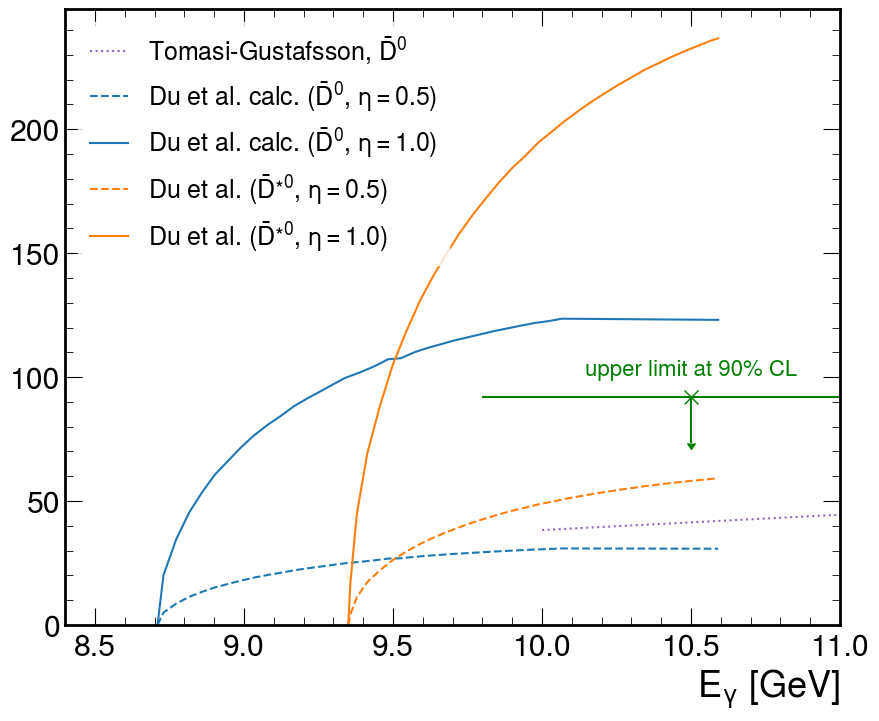

In [165]:
dfs=[pd.read_csv(StringIO(string), sep=",") for string in ("""nu,nb
8.71,0
8.730,5.024
8.773,8.664
8.817,11.386
8.859,13.359
8.901,15.112
8.946,16.537
8.988,17.849
9.033,19.104
9.079,20.177
9.123,21.071
9.168,22.070
9.213,22.859
9.257,23.572
9.302,24.315
9.339,24.916
9.391,25.496
9.439,26.112
9.484,26.805
9.526,26.902
9.572,27.509
9.618,27.963
9.661,28.318
9.707,28.710
9.752,29.022
9.796,29.337
9.843,29.664
9.888,29.940
9.931,30.201
9.977,30.466
10.022,30.643
10.066,30.891
10.591,30.773""","""nu,nb
9.350,0
9.357,4.255
9.379,11.270
9.414,17.338
9.456,22.073
9.499,26.214
9.543,29.499
9.592,32.795
9.636,35.251
9.678,37.383
9.722,39.453
9.767,41.344
9.809,42.936
9.854,44.582
9.899,46.058
9.941,47.238
9.987,48.636
10.032,49.737
10.074,50.776
10.121,51.826
10.166,52.775
10.209,53.599
10.256,54.474
10.301,55.241
10.344,55.991
10.390,56.642
10.435,57.302
10.477,57.852
10.524,58.418
10.570,58.970
10.591,59.163
""")]

plt.plot([10.0, 11.9, 17.0, 23.6, 30.2], [38.3, 50.1, 60.7, 68.1, 73.6], color='tab:purple', ls=':',
         label='Tomasi-Gustafsson, $\\bar D^0$')

plt.text(10.5, 101, "upper limit at 90% CL", fontsize=16, color='g', ha='center')
plt.errorbar([10.5], [92], [92/5],[[0.7],[0.5]], uplims=[1], color='g', marker='x', markersize=10)

labels='Du et al. calc. ($\\bar D^{0}$, $\\eta=0.5$)','Du et al. ($\\bar D^{\\ast 0}$, $\\eta=0.5$)' 
for i in range(2):
    a=plt.plot(dfs[i].nu, dfs[i].nb, ls='--', label=labels[i])
    plt.plot(dfs[i].nu, dfs[i].nb*4, ls='-', label=labels[i].replace("0.5", "1.0"), color=a[0].get_color())


plt.xlim(8.4,11)
plt.legend(fontsize=18)
plt.ylim(0)
plt.xlabel("$E_\\gamma$ [GeV]")

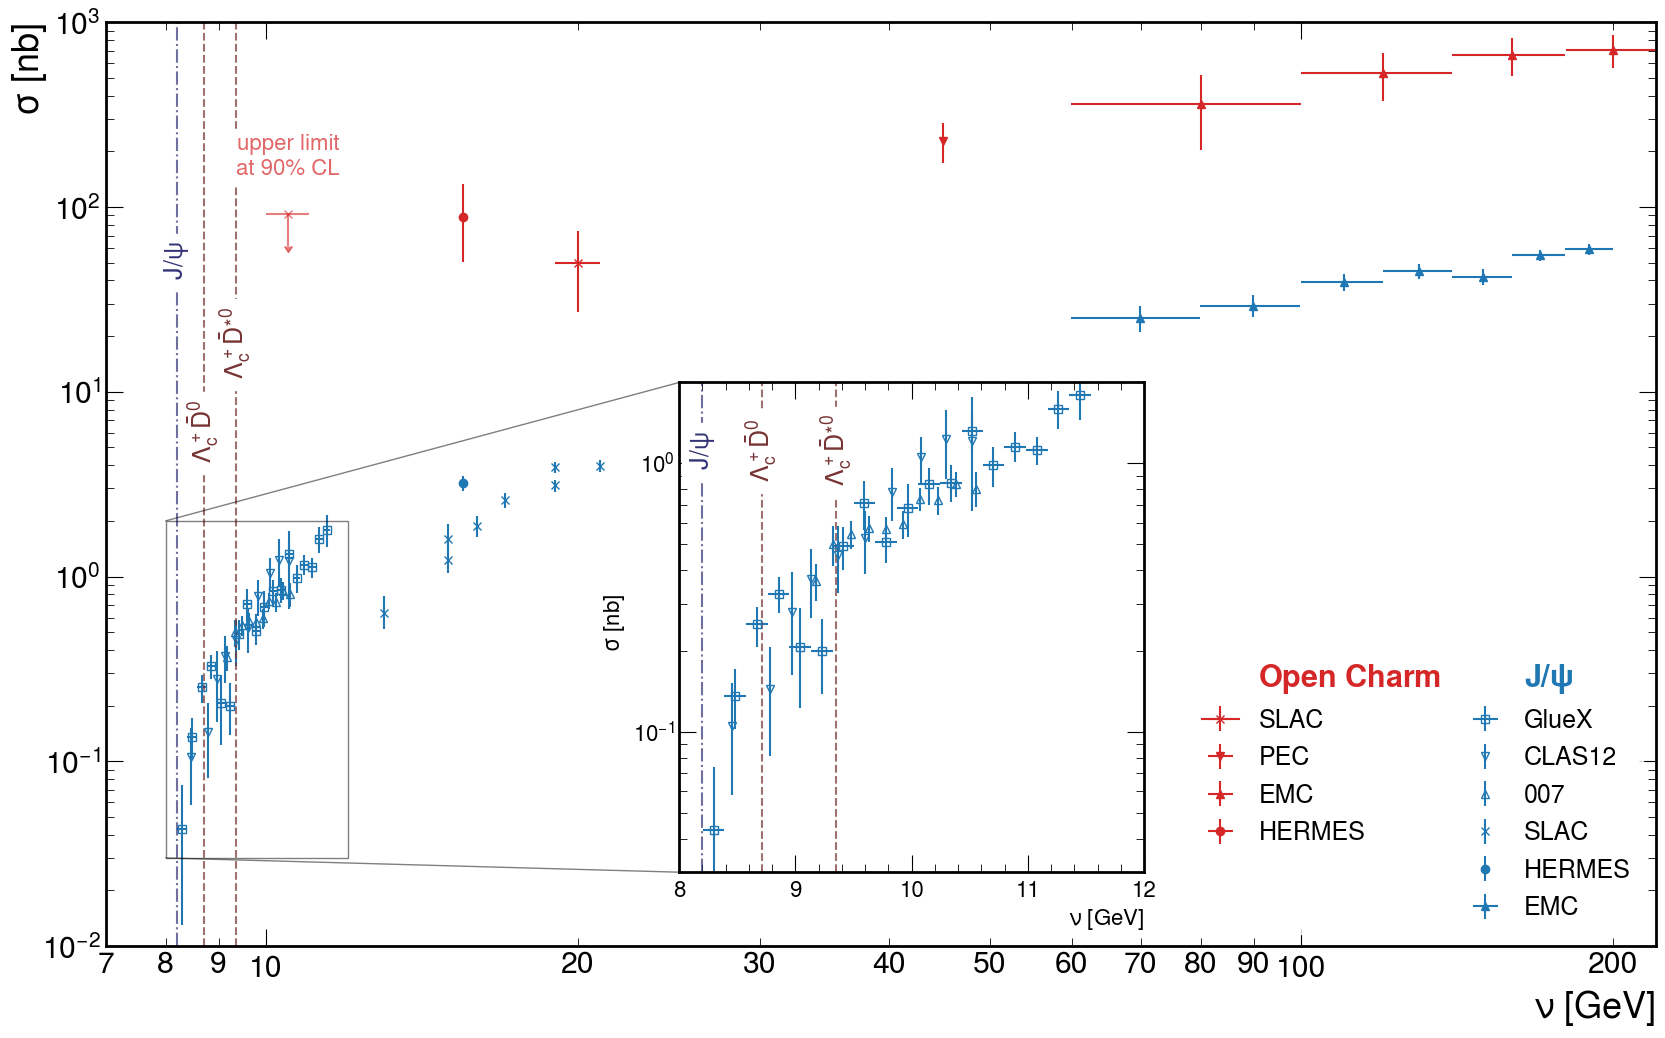

In [352]:
from io import StringIO
def plot_existing(color_open='r',color_closed='b', legend=True, hideText=False):
    
    plt.ylim(1e-2, 1e3)
    plt.yscale('log')
    plt.xlabel("$\\nu$ [GeV]")
    plt.xlim(6.5, 11.5)


    
    plt.errorbar([],[], color='w', label='$\\!\\!$Open Charm')
    plt.errorbar([20], [50], [[23],[24]],[1], label='SLAC', color=color_open, marker='x')


    


    data_str = StringIO("""nu,nb,dnb
    45.042,228.222,55
    """)
    data = pd.read_csv(data_str, sep=",")
    
    plt.errorbar(data.nu,data.nb, data.dnb, [0]*len(data), label='PEC', color=color_open, marker='v', ls='')
    
    data_str = StringIO("""nu,nb,dnb
    79.974,361.471,158
    119.898,529.415,153
    159.949,663.025,154
    200.128,710.027,145
    """)
    data = pd.read_csv(data_str, sep=",")
    
    plt.errorbar(data.nu,data.nb, data.dnb, [20]*len(data), label='EMC', color=color_open, marker='^', ls='')
    
    

    #87.9^{+40.7}_{-32.1} \mathrm{(stat)}\pm9.2 \mathrm{(sys)} \pm 17.6
    plt.errorbar([15.5], [87.9], [[np.sqrt(32.1**2+9.2**2+17.6**2)],[np.sqrt(40.7**2+9.2**2+17.6**2)]],[.1], label='HERMES', color=color_open, marker='o',ls='')

    #upper limit
    plt.errorbar([10.5], [92], [92/3],[0.5], uplims=[1], color=color_open, marker='x', alpha=0.6)


    #plt.plot([10.0, 11.9, 17.0, 23.6, 30.2], [38.3, 50.1, 60.7, 68.1, 73.6], color='tab:purple', ls='-.',
    #         label='Tomasi-Gustafsson calc, $\\bar D^0$')

    #get the legend to have two columns, one OC and the other J psi
    plt.errorbar([],[], label=" ", color='w')
    plt.errorbar([],[], label=" ", color='w')
    plt.errorbar([],[], label="$J/\\psi$", color='w')
    
    gluex_str = StringIO("""nu,nb,low,up
        8.297,0.043,0.013,0.074
        8.483,0.136,0.102,0.171
        8.669,0.251,0.207,0.292
        8.855,0.327,0.278,0.376
        9.041,0.207,0.123,0.288
        9.227,0.200,0.138,0.264
        9.407,0.491,0.401,0.580
        9.593,0.710,0.565,0.859
        9.779,0.510,0.427,0.594
        9.965,0.683,0.530,0.837
        10.151,0.837,0.701,0.963
        10.337,0.848,0.719,0.987
        10.523,1.322,1.121,1.539
        10.703,0.987,0.816,1.150
        10.890,1.150,1.013,1.305
        11.081,1.121,0.987,1.257
        11.262,1.599,1.339,1.862
        11.448,1.792,1.445,2.141
        """)

    gluex = pd.read_csv(gluex_str, sep=",")

    dx=(gluex.nu[1]-gluex.nu[0])/2
    plt.errorbar(gluex.nu, gluex.nb, [gluex.nb-gluex.low, gluex.up-gluex.nb],dx,
                 label='GlueX', color=color_closed, ls='', marker='s', fillstyle='none')

    clas12_str = StringIO("""nu,nb,dnb
        8.456,0.105,0.047
        8.784,0.144,0.063
        8.975,0.279,0.116
        9.132,0.372,0.107
        9.364,0.455,0.127
        9.603,0.525,0.139
        9.828,0.784,0.175
        10.084,1.051,0.207
        10.292,1.231,0.355
        10.521,1.213,0.550
        """)

    clas12 = pd.read_csv(clas12_str, sep=",")

    plt.errorbar(clas12.nu, clas12.nb, clas12.dnb,
                 label='CLAS12', color=color_closed, ls='', marker='v', fillstyle='none')


    hallc_str = StringIO("""nu,nb,dnb
    9.176,0.365,0.058
    9.327,0.499,0.084
    9.478,0.544,0.065
    9.629,0.573,0.063
    9.780,0.568,0.062
    9.924,0.594,0.071
    10.076,0.738,0.074
    10.227,0.731,0.087
    10.381,0.840,0.092
    10.552,0.805,0.120""")

    hallc = pd.read_csv(hallc_str, sep=",")

    plt.errorbar(hallc.nu, hallc.nb, hallc.dnb,
                 label='007', color=color_closed, ls='', marker='^', fillstyle='none')
    
    

    
    slac_jpsi_str= StringIO("""nu,nb,low,up
        13,0.637,0.519,0.782
        15,1.599,1.357,1.923
        15,1.224,1.039,1.503
        16,1.881,1.629,2.113
        17,2.609,2.354,2.832
        19,3.921,3.612,4.170
        19,3.129,2.882,3.327
        21,3.950,3.676,4.244
    """)
    slac_jpsi = pd.read_csv(slac_jpsi_str, sep=",")

    plt.errorbar(slac_jpsi.nu, slac_jpsi.nb, [slac_jpsi.nb-slac_jpsi.low, slac_jpsi.up-slac_jpsi.nb],
                 label='SLAC', color=color_closed, ls='', marker='x', fillstyle='none')


    plt.errorbar([15.5], [3.2], [0.3], label='HERMES', color=color_closed, marker='o',ls='')
    
    data_str = StringIO("""nu,nb
    69.866,25.004
    89.827,29.242
    110.045,39.218
    129.878,44.975
    149.840,41.998
    169.930,54.697
    189.891,59.150
    """)
    data = pd.read_csv(data_str, sep=",")
    
    plt.errorbar(data.nu,data.nb, [4]*len(data), [10]*len(data), label='EMC', color=color_closed, marker='^', ls='')

    if not hideText:
        plt.text(10.5, 1.5e2, "upper limit\nat 90% CL", fontsize=16, color=color_open, alpha=0.7,ha='center',bbox=dict(facecolor='white',edgecolor='white'))

    plt.xlim(7, 220)
    plt.xscale('log')

    
    if legend:
        leg=plt.legend(fontsize=18, loc='lower right',ncol=2,labelcolor=[color_open]+['k']*6+[color_closed]+['k']*6, columnspacing=1)
        leg.get_texts()[0].set_weight('bold')
        leg.get_texts()[0].set_fontsize(22)
        leg.get_texts()[0].set_horizontalalignment('center')
        leg.get_texts()[7].set_weight('bold')
        leg.get_texts()[7].set_fontsize(22)
    if not hideText:
        for thresh, lbl,y,ls,color in [(8.2," $J/\\psi$ ", 50, '-.','#333377'), (8.71, " $\\Lambda_c^+\\bar D^0$ ",6, '--','#773333'), (9.35, " $\\Lambda_c^+\\bar D^{\\ast 0}$ ",18,'--','#773333')]:
            plt.axvline(thresh, alpha=0.7, ls=ls,color=color)
            plt.text(thresh, y, lbl,  rotation=90, fontsize=18,ha='center',va='center',bbox=dict(facecolor='white',edgecolor='white'),color=color)
    
    plt.ylabel("$\\sigma$ [nb]", labelpad=-5)

    ax=plt.gca()
    # 1. Add inset axes (location and size)
    axins = ax.inset_axes([0.37, 0.08, 0.3, 0.53]) 
    
    # 2. Define subregion to zoom in on
    x1, x2, y1, y2 = 8, 12, 3e-2, 2
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)

    axins.tick_params(axis='both', labelsize=16)
    #axins.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))

    axins.errorbar(clas12.nu, clas12.nb, clas12.dnb,
                 label='CLAS12', color=color_closed, ls='', marker='v', fillstyle='none')
    axins.errorbar(hallc.nu, hallc.nb, hallc.dnb,
                 label='007', color=color_closed, ls='', marker='^', fillstyle='none')
    axins.errorbar(gluex.nu, gluex.nb, [gluex.nb-gluex.low, gluex.up-gluex.nb],dx,
                 label='GlueX', color=color_closed, ls='', marker='s', fillstyle='none')
    axins.set_yscale('log')
    axins.set_xlabel("$\\nu$ [GeV]", fontsize=16)
    axins.set_ylabel("$\\sigma$ [nb]                                   ", fontsize=16)

    for thresh, lbl,y,ls,color in [(8.2," $J/\\psi$ ", 1.1, '-.','#333377'), (8.71, " $\\Lambda_c^+\\bar D^0$ ",1.1, '--','#773333'), (9.35, " $\\Lambda_c^+\\bar D^{\\ast 0}$ ",1.1,'--','#773333')]:
        axins.axvline(thresh, alpha=0.7, ls=ls,color=color)
        axins.text(thresh, y, lbl,  rotation=90, fontsize=18,ha='center',va='center',bbox=dict(facecolor='white',edgecolor='white'),color=color)

    
    # 3. Add indicator box and connector lines
    ax.indicate_inset_zoom(axins, edgecolor="black")
    
fig,axs=plt.subplots(1,1,figsize=(20,12))
plot_existing('tab:red','tab:blue', legend=True)
ax=plt.gca()
import matplotlib as mpl
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
#ax.xaxis.set_minor_formatter(mpl.ticker.LogFormatter())
ax.xaxis.set_minor_formatter(mpl.ticker.ScalarFormatter())
#ax.ticklabel_format(style='plain',axis='x',useOffset=False)
plt.savefig("images/existing_data.pdf")

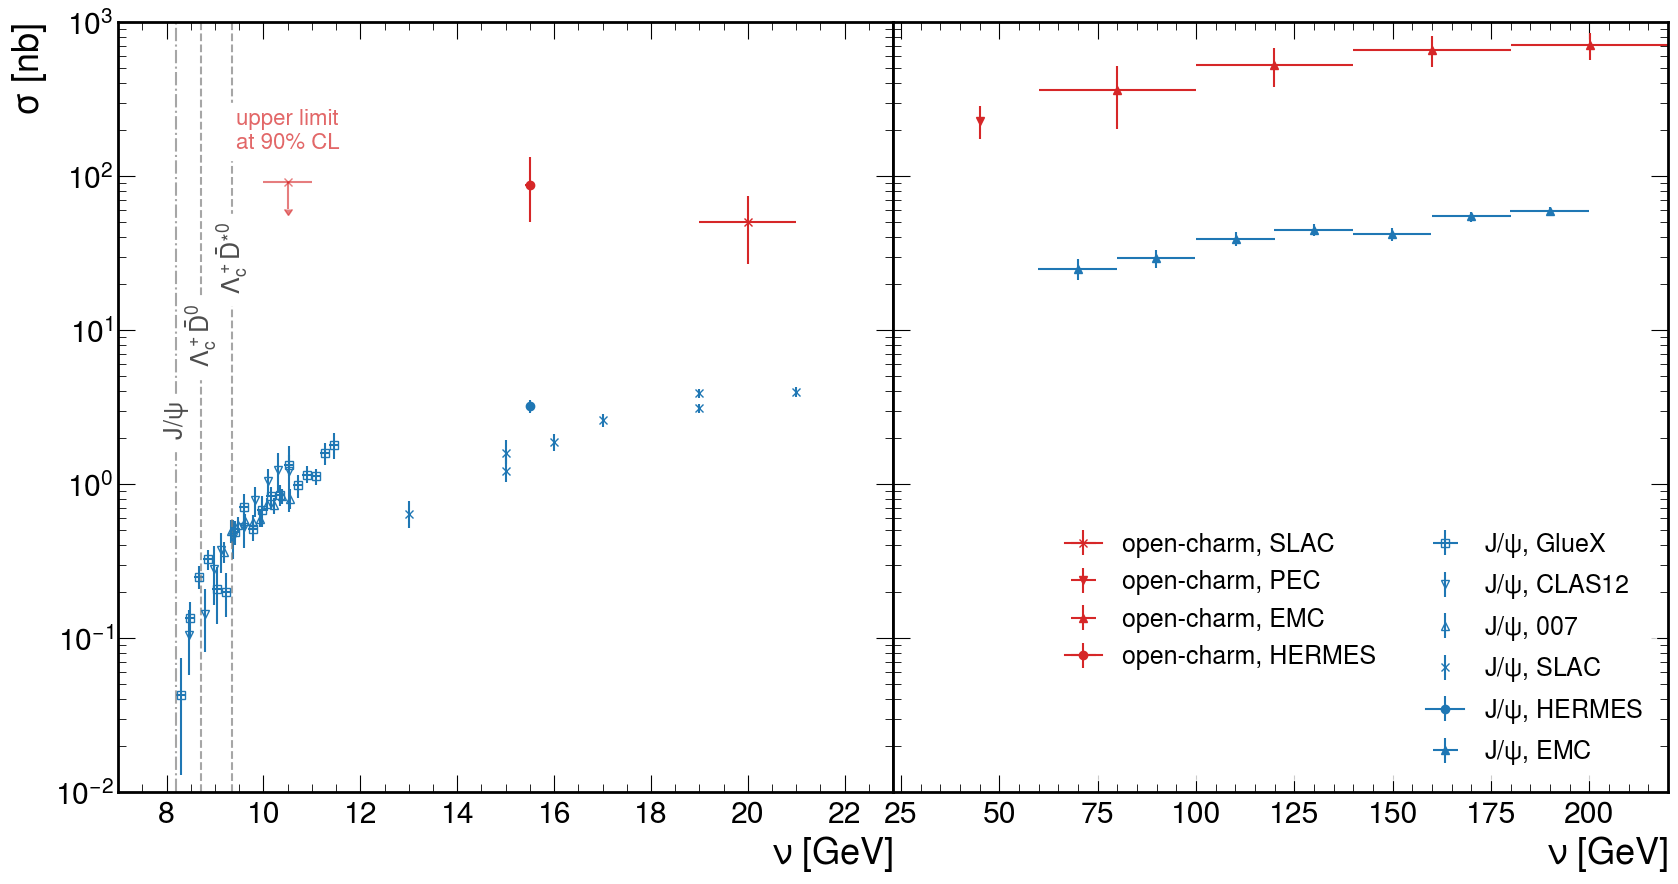

In [273]:
fig,axs=plt.subplots(1,2,figsize=(20,10),sharey='all')
plt.subplots_adjust(wspace=0)
plt.sca(axs[0])
plot_existing('tab:red','tab:blue', legend=False, hideText=False)
plt.xlim(7, 23)
plt.xscale('linear')
plt.gca().xaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
plt.sca(axs[1])
plot_existing('tab:red','tab:blue', legend=True, hideText=True)
plt.xlim(23, 220)
plt.ylabel("")
plt.xscale('linear')


In [337]:
help(plt.legend)

Help on function legend in module matplotlib.pyplot:

legend(*args, **kwargs) -> 'Legend'
    Place a legend on the Axes.
    
    Call signatures::
    
        legend()
        legend(handles, labels)
        legend(handles=handles)
        legend(labels)
    
    The call signatures correspond to the following different ways to use
    this method:
    
    **1. Automatic detection of elements to be shown in the legend**
    
    The elements to be added to the legend are automatically determined,
    when you do not pass in any extra arguments.
    
    In this case, the labels are taken from the artist. You can specify
    them either at artist creation or by calling the
    :meth:`~.Artist.set_label` method on the artist::
    
        ax.plot([1, 2, 3], label='Inline label')
        ax.legend()
    
    or::
    
        line, = ax.plot([1, 2, 3])
        line.set_label('Label via method')
        ax.legend()
    
    .. note::
        Specific artists can be excluded from the a

0
3
7
7
7
6
5
6
6
7
6
0


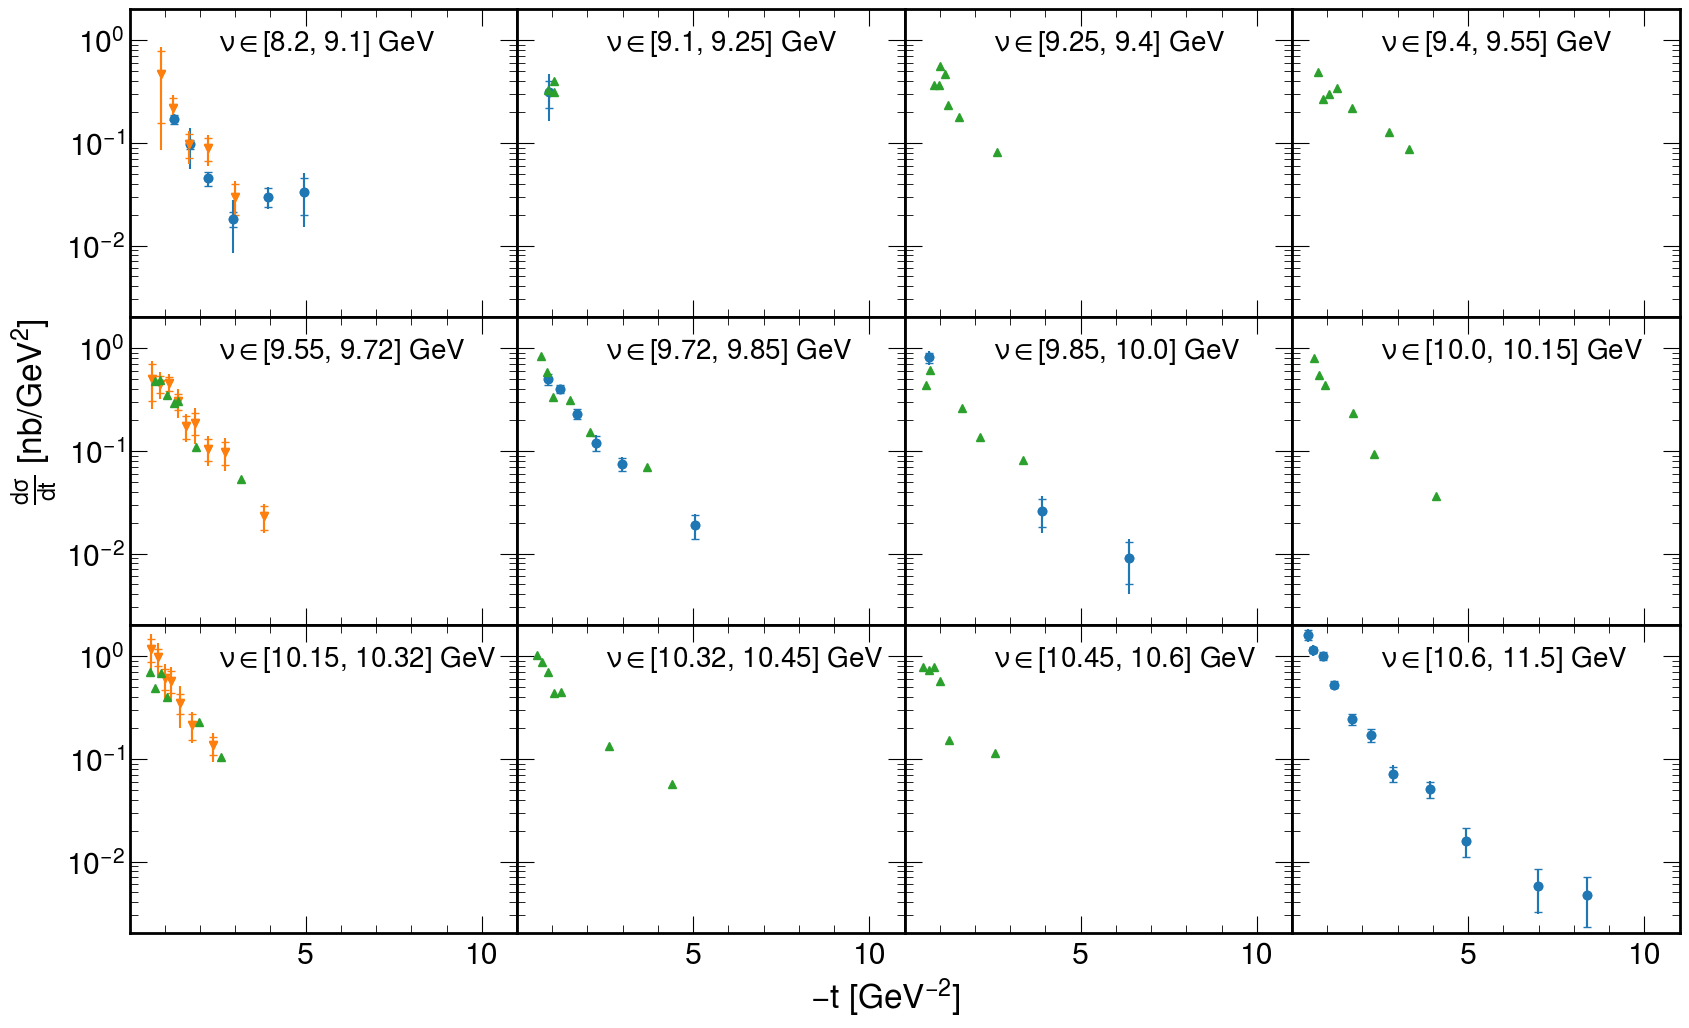

In [49]:
fig, axs=plt.subplots(3,4, figsize=(20,12),sharex='all', sharey='all')
plt.subplots_adjust(wspace=0, hspace=0)
plt.yscale('log')
plt.ylim(2e-3,2e0)
plt.xlim(0.001, 11)
axs[1][0].set_ylabel("$\\frac{d\\sigma}{dt}$ [nb/GeV$^2$]", fontsize=24)
axs[2][2].set_xlabel("$-t$ [GeV$^{-2}$]", fontsize=24, x=-0.05)

from io import StringIO

#[8.2, 9.28] GeV, [9.28, 10.00] GeV, and
#[10.0, 10.6] GeV


clas12_t=pd.read_csv(StringIO("""nu,t,sigma,stat,syst
8.6,0.9,0.473,0.316,0.225
8.6,1.24,0.221,0.054,0.044
8.6,1.7,0.097,0.026,0.023
8.6,2.23,0.089,0.023,0.019
8.6,2.98,0.03,0.01,0.008
9.6,0.64,0.506,0.201,0.146
9.6,0.87,0.451,0.088,0.1
9.6,1.12,0.457,0.07,0.073
9.6,1.37,0.305,0.057,0.08
9.6,1.6,0.175,0.043,0.029
9.6,1.87,0.189,0.045,0.055
9.6,2.22,0.105,0.026,0.022
9.6,2.72,0.098,0.025,0.024
9.6,3.81,0.023,0.006,0.004
10.2,0.6,1.176,0.291,0.356
10.2,0.8,0.991,0.179,0.3
10.2,1,0.609,0.143,0.179
10.2,1.19,0.575,0.137,0.156
10.2,1.43,0.354,0.078,0.135
10.2,1.78,0.213,0.06,0.037
10.2,2.36,0.136,0.027,0.034"""), sep=",")


gluex_t=pd.read_csv(StringIO("""nu,t,sigma,stat,syst
9.14,0.92,0.313,0.092,0.12
8.96,1.25,0.17,0.018,0.008
8.8,1.72,0.097,0.01,0.04
8.77,2.24,0.045,0.007,0.003
8.78,2.94,0.018,0.003,0.009
8.95,3.92,0.03,0.006,0.004
9.1,4.95,0.033,0.013,0.012
10,0.69,0.813,0.088,0.092
9.85,0.87,0.499,0.061,0.016
9.83,1.21,0.401,0.037,0.01
9.83,1.71,0.231,0.027,0.006
9.82,2.24,0.12,0.021,0.007
9.84,2.97,0.075,0.011,0.005
9.86,3.89,0.026,0.008,0.006
9.76,5.06,0.019,0.005,0.002
9.93,6.37,0.009,0.004,0.003
10.96,0.46,1.611,0.187,0.139
10.87,0.6,1.15,0.084,0.109
10.85,0.88,1.015,0.089,0.023
10.86,1.18,0.529,0.042,0.023
10.86,1.69,0.242,0.029,0.008
10.83,2.24,0.17,0.025,0.003
10.82,2.87,0.072,0.012,0.008
10.81,3.92,0.051,0.009,0.002
10.78,4.93,0.016,0.005,0.001
10.7,6.97,0.0058,0.0026,0.0008
10.7,8.36,0.0047,0.0024,0.0002"""), sep=",")

c007_t=pd.read_csv(StringIO("""nu,t,sigma
9.2,0.88851351,0.32412077
9.2,1.04054054,0.40160044
9.2,1.05067568,0.31343959
9.3,0.82711864,0.36856909
9.3,0.96949153,0.36794998
9.3,1.02033898,0.56252706
9.3,1.16271186,0.47042481
9.3,1.24406780,0.23140924
9.3,1.53898305,0.17996001
9.3,2.63728814,0.08148584
9.5,0.74576271,0.49238826
9.5,0.86779661,0.26963063
9.5,1.05084746,0.29986313
9.5,1.26440678,0.34551073
9.5,1.69152542,0.21800253
9.5,2.74915254,0.12814224
9.5,3.31864407,0.08678837
9.6,0.72542373,0.47765401
9.6,0.87796610,0.49577008
9.6,1.05084746,0.34859466
9.6,1.27457627,0.29278241
9.6,1.36610169,0.30366795
9.6,1.87457627,0.10935853
9.6,3.16610169,0.05277144
9.8,0.68474576,0.83767764
9.8,0.83728814,0.58780161
9.8,1.03050847,0.33348548
9.8,1.50847458,0.31067599
9.8,2.05762712,0.15297321
9.8,3.68474576,0.07017038
9.9,0.62372881,0.44274518
9.9,0.72542373,0.60899732
9.9,1.64067797,0.26024633
9.9,2.14915254,0.13755030
9.9,3.35932203,0.08085229
10.1,0.61486486,0.80685969
10.1,0.76689189,0.54712356
10.1,0.93918919,0.44218655
10.1,1.73986486,0.23265998
10.1,2.31756757,0.09264781
10.1,4.08108108,0.03638430
10.3,0.58305085,0.70360391
10.3,0.73559322,0.49505846
10.3,0.88813559,0.67929915
10.3,1.06101695,0.40091604
10.3,1.97627119,0.22844341
10.3,2.60677966,0.10541460
10.4,0.56418919,1.03898245
10.4,0.71621622,0.87306385
10.4,0.86824324,0.70829900
10.4,1.04054054,0.43386339
10.4,1.25337838,0.45050884
10.4,2.62162162,0.13375661
10.4,4.40540541,0.05671705
10.5,0.53220339,0.78038281
10.5,0.68474576,0.72700678
10.5,0.82711864,0.78038281
10.5,1.00000000,0.56734359
10.5,1.25423729,0.15297321
10.5,2.56610169,0.11522281"""), sep=",")



nubins=[8.20,9.10, 9.25, 9.40, 9.55, 9.72, 9.85, 10.00, 10.15, 10.32, 10.45, 10.60, 11.50]
for i in range(12):
    axs[i//4][i%4].text(2.5, .8, f"$\\nu\\in$[{nubins[i]}, {nubins[i+1]}] GeV", fontsize=20)
    q=f"{nubins[i]}<nu<={nubins[i+1]}"
    dfq=gluex_t.query(q)
    a=axs[i//4][i%4].errorbar(dfq.t, dfq.sigma, dfq.stat, capsize=3, color='tab:blue', marker='o', ls='')
    axs[i//4][i%4].errorbar(dfq.t, dfq.sigma, np.hypot(dfq.stat,dfq.syst), color=a[0].get_color(), marker='o', ls='')
    

    
    dfq=clas12_t.query(q)
    a=axs[i//4][i%4].errorbar(dfq.t, dfq.sigma, dfq.stat, capsize=3, color='tab:orange', marker='v', ls='')
    axs[i//4][i%4].errorbar(dfq.t, dfq.sigma, np.hypot(dfq.stat,dfq.syst), color=a[0].get_color(), marker='v', ls='')

    
    dfq=c007_t.query(q)
    print(len(dfq))
    a=axs[i//4][i%4].errorbar(dfq.t, dfq.sigma, capsize=3, color='tab:green', marker='^', ls='')

